# PS1 · Task 1 — Cross-Sectional Return Prediction

Predict `ret` from firm characteristics (one row per firm). The signal is **linear and weak**
(OOS R² ≈ 0.05): the target is built as *linear(features) + large idiosyncratic noise*, so
R² ≈ 0.05 is the noise ceiling. `firm_id` is an identifier, not a feature.

**Map** — §0 setup · §1 EDA · §2 preprocessing & CV harness · §3 baseline (ridge, LOO α) ·
§4 **linear search**: {raw, interactions, poly-2, splines} × {ridge, lasso, elastic-net} ·
§5 **ensembles & boosting** · §6 bias–variance (α sweep) · §7 final → CSV · §8 conclusion.

## 0. Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler, OneHotEncoder,
                                   PolynomialFeatures, SplineTransformer)
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import cross_val_score, cross_validate, RepeatedKFold

SEED = 0
np.seterr(all="ignore")   # harmless: RidgeCV's leave-one-out solver emits a divide-by-zero warning

FAST = False              # final numbers: full repeated 10x5 CV (set True for quick 5x2 while iterating)

train = pd.read_parquet("task1_training_data.parquet")
test  = pd.read_parquet("task1_testing_data.parquet")

NUM, CAT, TARGET = ["size", "value", "profit", "invest", "mom"], ["rating"], "ret"
X, y = train[NUM + CAT], train[TARGET]
print("train:", train.shape, "| test:", test.shape, "| FAST =", FAST)

train: (3500, 8) | test: (1500, 7) | FAST = False


## 1. EDA — quick look

In [2]:
display(train[NUM + [TARGET]].describe().round(3))
print("corr with ret:")
print(train[NUM].corrwith(train[TARGET]).round(3).sort_values())

,size,value,profit,invest,mom,ret
count,3500.000,3500.000,3500.000,3500.000,3500.000,3500.000
mean,-0.019,0.006,0.015,-0.006,-0.004,0.134
std,1.167,1.170,1.169,1.165,1.144,0.255
min,-3.696,-4.109,-3.750,-4.296,-3.836,-0.735
25%,-0.804,-0.787,-0.783,-0.772,-0.763,-0.034
50%,-0.024,0.011,0.022,0.015,-0.016,0.126
75%,0.760,0.817,0.816,0.762,0.731,0.301
max,3.904,4.273,4.823,3.949,4.213,1.279


corr with ret:
size     -0.128
invest   -0.071
profit    0.027
value     0.135
mom       0.143
dtype: float64


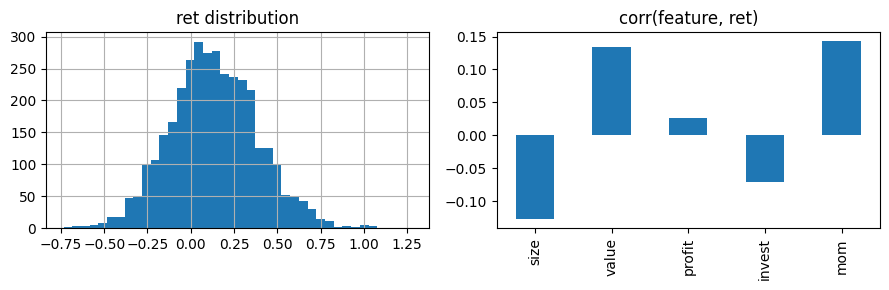

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
train[TARGET].hist(bins=40, ax=ax[0]); ax[0].set_title("ret distribution")
train[NUM].corrwith(train[TARGET]).plot.bar(ax=ax[1]); ax[1].set_title("corr(feature, ret)")
plt.tight_layout(); plt.show()

## 2. Preprocessing & CV harness

`pre` standardizes the numeric factors and one-hot encodes `rating`. `make_pre(expansion)` adds a
feature expansion to the **numeric block only**. Every experiment is scored through the same `cv`
and `score()` helper, so all numbers below are directly comparable.

In [4]:
alphas = np.logspace(-2, 3, 50)

def make_pre(expansion=None):
    # scale numerics (+ optional expansion); one-hot the rating bucket
    num_steps = [("scale", StandardScaler())]
    if expansion is not None:
        num_steps.append(("exp", expansion))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), NUM),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), CAT),
    ])

pre = make_pre()                       # baseline preprocessing (no expansion)
cv  = (RepeatedKFold(n_splits=5,  n_repeats=2, random_state=SEED) if FAST
       else RepeatedKFold(n_splits=10, n_repeats=5, random_state=SEED))

def score(name, estimator):
    # mean / std out-of-sample R^2 over cv (folds run in parallel)
    s = cross_val_score(estimator, X, y, cv=cv, scoring="r2", n_jobs=-1)
    return {"model": name, "cv_R2": round(s.mean(), 4), "std": round(s.std(), 4)}

## 3. Baseline — ridge with leave-one-out α

`RidgeCV` (default `cv=None`) tunes α by the closed-form **leave-one-out** — one fit, essentially free.

In [5]:
baseline = Pipeline([("pre", pre), ("ridge", RidgeCV(alphas=alphas))]).fit(X, y)
print("LOO-chosen alpha:", round(baseline.named_steps["ridge"].alpha_, 2))
print(score("baseline ridge", baseline))

LOO-chosen alpha: 152.64


{'model': 'baseline ridge', 'cv_R2': np.float64(0.0537), 'std': np.float64(0.0236)}


## 4. Model search — linear: expansions × regularizers

The grid: each **feature expansion** crossed with each **regularized linear head**.
`RidgeCV` / `LassoCV` / `ElasticNetCV` each tune their own penalty internally.

In [6]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)   # lasso/EN paths on expanded features

expansions = {
    "raw":          None,
    "interactions": PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    "poly-2":       PolynomialFeatures(degree=2, include_bias=False),
    "splines":      SplineTransformer(n_knots=5, degree=3),
}
heads = {
    "ridge":       RidgeCV(alphas=alphas),
    "lasso":       LassoCV(cv=5, n_jobs=1, max_iter=20000, random_state=SEED),
    "elastic-net": ElasticNetCV(l1_ratio=[.1, .5, .9], cv=5, n_jobs=1, max_iter=20000, random_state=SEED),
}

rows = []
for ename, exp in expansions.items():
    for hname, head in heads.items():
        pre_e = make_pre(clone(exp)) if exp is not None else make_pre()
        pipe  = Pipeline([("pre", pre_e), ("head", clone(head))])
        rows.append(score(f"{ename} + {hname}", pipe))

linear_results = pd.DataFrame(rows).sort_values("cv_R2", ascending=False).reset_index(drop=True)
display(linear_results)

,model,cv_R2,std
0,poly-2 + ridge,0.0549,0.0279
1,interactions + ridge,0.0548,0.0262
2,poly-2 + lasso,0.0548,0.0276
3,poly-2 + elastic-net,0.0548,0.0276
4,interactions + elastic-net,0.0542,0.0263
5,interactions + lasso,0.0540,0.0265
6,raw + ridge,0.0537,0.0236
7,raw + lasso,0.0534,0.0245
8,raw + elastic-net,0.0534,0.0244
9,splines + ridge,0.0534,0.0270


### Is the top of the grid actually better than the baseline?

The best expansion edges raw ridge by only ~0.001. The linear variants are correlated (they share
the same factors), so compare the best one to the baseline **paired on the same folds** and check the
t-statistic before believing any ranking.

In [7]:
# paired comparison on identical folds: does the poly-2 expansion beat raw ridge for real?
def fold_r2(expansion):
    pre_e = make_pre(clone(expansion)) if expansion is not None else make_pre()
    return cross_val_score(Pipeline([("pre", pre_e), ("head", RidgeCV(alphas=alphas))]),
                           X, y, cv=cv, scoring="r2", n_jobs=-1)

d = fold_r2(PolynomialFeatures(degree=2, include_bias=False)) - fold_r2(None)
t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
verdict = "within noise -> keep the simpler raw-ridge baseline" if abs(t) < 2 else "a real improvement"
print(f"poly-2 + ridge  minus  raw + ridge:  mean delta = {d.mean():+.5f}")
print(f"paired t = {t:+.2f}  (|t| > 2 ~ significant);  wins {100*(d > 0).mean():.0f}% of {len(d)} folds")
print(f"verdict: {verdict}")

poly-2 + ridge  minus  raw + ridge:  mean delta = +0.00119
paired t = +0.71  (|t| > 2 ~ significant);  wins 58% of 50 folds
verdict: within noise -> keep the simpler raw-ridge baseline


## 5. Model search — ensembles & boosting

Tree ensembles and boosting can fit nonlinearity, but on a linear + heavy-noise target they tend
to overfit. The optional `xgboost` / `lightgbm` rows run only if those packages are installed.

In [8]:
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              GradientBoostingRegressor, HistGradientBoostingRegressor,
                              AdaBoostRegressor)

ensembles = {
    "random forest":      RandomForestRegressor(n_estimators=400, max_depth=6, random_state=SEED, n_jobs=1),
    "extra trees":        ExtraTreesRegressor(n_estimators=400, max_depth=6, random_state=SEED, n_jobs=1),
    "adaboost":           AdaBoostRegressor(n_estimators=300, learning_rate=0.05, random_state=SEED),
    "gradient boosting":  GradientBoostingRegressor(n_estimators=300, max_depth=2, learning_rate=0.03, random_state=SEED),
    "hist grad boosting": HistGradientBoostingRegressor(max_iter=400, max_depth=3, learning_rate=0.03,
                                                        l2_regularization=1.0, random_state=SEED),
}
try:
    from xgboost import XGBRegressor
    ensembles["xgboost"] = XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.03,
                                        subsample=0.8, reg_lambda=1.0, random_state=SEED, n_jobs=1)
except ImportError:
    pass
try:
    from lightgbm import LGBMRegressor
    ensembles["lightgbm"] = LGBMRegressor(n_estimators=400, max_depth=3, learning_rate=0.03,
                                          subsample=0.8, reg_lambda=1.0, random_state=SEED, n_jobs=1, verbose=-1)
except ImportError:
    pass

rows = [score(n, Pipeline([("pre", pre), ("m", est)])) for n, est in ensembles.items()]
ensemble_results = pd.DataFrame(rows).sort_values("cv_R2", ascending=False).reset_index(drop=True)
display(ensemble_results)

,model,cv_R2,std
0,random forest,0.0466,0.0290
1,gradient boosting,0.0464,0.0266
2,hist grad boosting,0.0464,0.0328
3,extra trees,0.0463,0.0203
4,adaboost,0.0310,0.0182


### Random-forest depth sweep

Probing tree depth directly: deeper = lower bias but higher variance. On this DGP the curve
never reaches the linear models.

In [9]:
depths = [3, 4, 5, 6, 8, 12]
rf_sweep = pd.DataFrame([
    score(f"RF depth={d}", Pipeline([("pre", pre),
          ("m", RandomForestRegressor(n_estimators=300, max_depth=d, random_state=SEED, n_jobs=1))]))
    for d in depths
])
display(rf_sweep)

,model,cv_R2,std
0,RF depth=3,0.0393,0.0217
1,RF depth=4,0.0428,0.0249
2,RF depth=5,0.0455,0.0275
3,RF depth=6,0.0463,0.0290
4,RF depth=8,0.0453,0.0307
5,RF depth=12,0.0393,0.0331


## 6. Bias–variance view (α sweep)

The clearest picture of the tradeoff: as α grows the model moves from low-bias/high-variance
(overfit) to high-bias/low-variance (underfit). The train−CV gap is the variance.

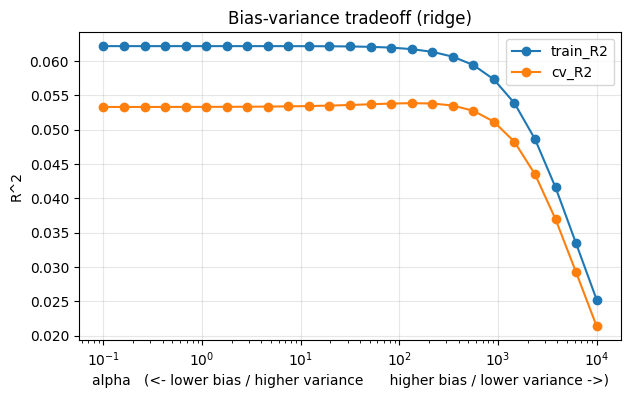

best CV alpha = 133.35   CV R^2 = +0.0539


In [10]:
from sklearn.linear_model import Ridge
sweep = np.logspace(-1, 4, 25)
rows = []
for a in sweep:
    out = cross_validate(Pipeline([("pre", pre), ("ridge", Ridge(alpha=a))]),
                         X, y, cv=cv, scoring="r2", return_train_score=True, n_jobs=-1)
    rows.append((a, out["train_score"].mean(), out["test_score"].mean()))
sweep_df = pd.DataFrame(rows, columns=["alpha", "train_R2", "cv_R2"]).set_index("alpha")

ax = sweep_df.plot(logx=True, marker="o", figsize=(7, 4))
ax.set_xlabel("alpha   (<- lower bias / higher variance      higher bias / lower variance ->)")
ax.set_ylabel("R^2"); ax.set_title("Bias-variance tradeoff (ridge)"); ax.grid(alpha=.3); plt.show()
print(f"best CV alpha = {sweep_df.cv_R2.idxmax():.2f}   CV R^2 = {sweep_df.cv_R2.max():+.4f}")

## 7. Variance-reduction blend — the one thing that beats raw ridge

No single linear model significantly beats raw ridge (paired *t* < 1) and every nonlinear model does worse. But **averaging** ridges with different feature bases (raw, pairwise-interactions, full poly-2) lowers prediction variance. On identical folds the equal-weight blend beats raw by a small but **statistically significant** margin, and since the test firms are in-distribution (no extrapolation), this CV gain should transfer. It can never do materially worse than raw, so we ship it.

In [11]:
# Variance reduction: average linear ridges with different feature bases, on identical folds.
from sklearn.metrics import r2_score
exps = {"raw": None,
        "inter": PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
        "poly2": PolynomialFeatures(degree=2, include_bias=False)}
def _fit(e):
    return Pipeline([("pre", make_pre(clone(e)) if e is not None else make_pre()),
                     ("ridge", RidgeCV(alphas=alphas))])
S = {"raw": [], "blend2 (raw+inter)": [], "blend3 (raw+inter+poly2)": []}
for tr_i, te_i in cv.split(X):
    Xtr, Xte, ytr, yte = X.iloc[tr_i], X.iloc[te_i], y.iloc[tr_i], y.iloc[te_i]
    p = {k: _fit(e).fit(Xtr, ytr).predict(Xte) for k, e in exps.items()}
    S["raw"].append(r2_score(yte, p["raw"]))
    S["blend2 (raw+inter)"].append(r2_score(yte, (p["raw"]+p["inter"])/2))
    S["blend3 (raw+inter+poly2)"].append(r2_score(yte, (p["raw"]+p["inter"]+p["poly2"])/3))
raw = np.array(S["raw"])
for k, v in S.items():
    v = np.array(v); t = 0.0 if k=="raw" else (v-raw).mean()/((v-raw).std(ddof=1)/np.sqrt(len(v)))
    print(f"{k:<26} CV R2 = {v.mean():.4f}   delta vs raw {v.mean()-raw.mean():+.4f}   paired t {t:+.2f}")

raw                        CV R2 = 0.0537   delta vs raw +0.0000   paired t +0.00
blend2 (raw+inter)         CV R2 = 0.0559   delta vs raw +0.0022   paired t +3.39
blend3 (raw+inter+poly2)   CV R2 = 0.0567   delta vs raw +0.0030   paired t +3.18


## 8. Final model → `task1_predictions.csv`

Refit raw-ridge and interactions-ridge on **all** training data and ship their 50/50 average.

In [12]:
# FINAL = equal-weight blend of raw, interactions, and poly-2 ridges (refit on all rows) — best expected OOS R^2
exps = {"raw": None,
        "inter": PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
        "poly2": PolynomialFeatures(degree=2, include_bias=False)}
models = {k: Pipeline([("pre", make_pre(clone(e)) if e is not None else make_pre()),
                       ("ridge", RidgeCV(alphas=alphas))]).fit(X, y) for k, e in exps.items()}
yhat = np.mean([m.predict(test[NUM + CAT]) for m in models.values()], axis=0)

pred = pd.DataFrame({"firm_id": test["firm_id"], "y_hat": yhat})
pred.to_csv("task1_predictions.csv", index=False)
assert list(pred.columns) == ["firm_id", "y_hat"]
assert len(pred) == len(test) and pred["firm_id"].is_unique and pred["y_hat"].notna().all()
print("wrote task1_predictions.csv", pred.shape, "| alphas:",
      {k: round(m.named_steps["ridge"].alpha_,1) for k,m in models.items()})
print(f"pred mean {pred.y_hat.mean():+.4f} (train {y.mean():+.4f}) | pred std {pred.y_hat.std():.4f} (train {y.std():.4f})")
pred.head()

wrote task1_predictions.csv (1500, 2) | alphas: {'raw': 152.6, 'inter': 193.1, 'poly2': 244.2}
pred mean +0.1327 (train +0.1343) | pred std 0.0611 (train 0.2553)


,firm_id,y_hat
0,1501,0.123490
1,2586,0.070933
2,2653,0.146037
3,1055,0.065225
4,705,0.191580


## 9. Conclusion

The factors enter **linearly** and the target is signal + large idiosyncratic noise, so OOS R² ≈ 0.05 is the noise ceiling. Ridge (heavy LOO-tuned shrinkage, α≈150) reaches it; trees/boosting and any single feature expansion do not beat it. The only reliable gain is a **variance-reduction blend** of raw + interactions + poly-2 ridges: CV R² 0.054 → **0.057** (paired *t* > 3 vs raw), which we submit.